In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
jj_eps = pd.read_csv("/content/drive/MyDrive/2026/Time Series Analysis/Dataset/JJ_Quaterly_EPS.csv", usecols = ['time', 'value'])
jj_eps.columns = ['date', 'EPS']

################################################# Format date column #################################################
# Extract year
jj_eps['year'] = jj_eps['date'].astype(int)

# Extract quarter number (0,1,2,3)
jj_eps['quarter'] = ((jj_eps['date'] - jj_eps['year']) * 4).round().astype(int) + 1

# Convert to proper datetime
jj_eps['date'] = pd.to_datetime(jj_eps['year'].astype(str) + 'Q' + jj_eps['quarter'].astype(str))

# Drop helper columns
jj_eps = jj_eps.drop(columns=['year', 'quarter'])
jj_eps = jj_eps.set_index("date")
##############################################################################################################################
jj_eps.head(3)

,EPS
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-01,0.85


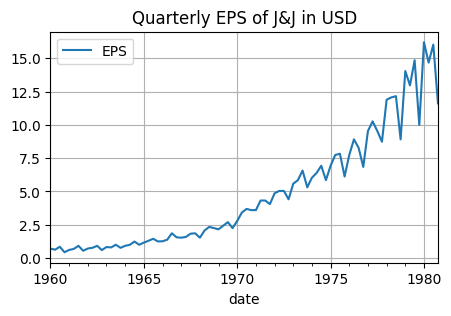

In [4]:
jj_eps.plot(figsize = (5, 3))
plt.grid(True)
plt.title("Quarterly EPS of J&J in USD")
plt.show()

### Approach 1. Forecast using historical mean.

In [5]:
train = jj_eps[:-4]
test = jj_eps[-4:]

hist_mean = np.round(np.mean(train), 2)
print("Historical Mean: ", hist_mean)

test['pred_mean'] = hist_mean
print("MAPE: ", mean_absolute_percentage_error(test['EPS'], test['pred_mean']))

Historical Mean:  4.31
MAPE:  0.699970838624719


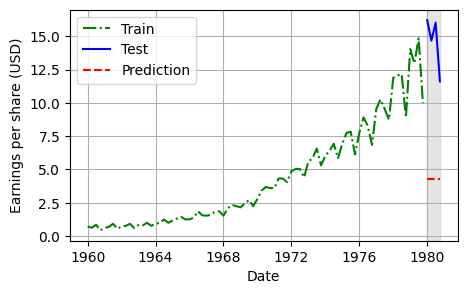

In [6]:
plt.figure(figsize = (5, 3))
plt.plot(train.index, train['EPS'], 'g-.', label='Train')
plt.plot(test.index, test['EPS'], 'b-', label='Test')
plt.plot(test.index, test['pred_mean'], 'r--', label='Prediction')
plt.axvspan('1980-01-01', '1980-10-01', color='#808080', alpha=0.2)
plt.ylabel('Earnings per share (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

Baseline deviates by 70% on average from the observed values.
<br>**Problem**: The lesson learned from the previous baseline is that earlier values do not seem to be predictive of future values in the long term because of the positive trend component in our dataset.

### Approach 2. Forecast using last year mean.

In [7]:
last_year_mean = np.mean(train.EPS[-4:])
print("Last Year Mean Mean: ", last_year_mean)

test['pred_last_yr_mean'] = last_year_mean
print("MAPE: ", mean_absolute_percentage_error(test['EPS'], test['pred_last_yr_mean']))

Last Year Mean Mean:  12.96
MAPE:  0.155963680725103


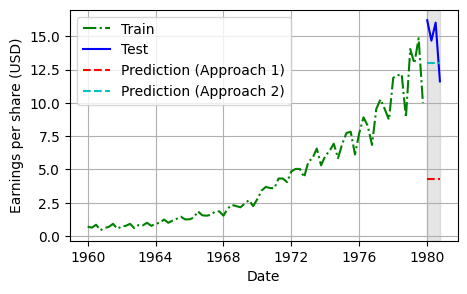

In [8]:
plt.figure(figsize = (5, 3))
plt.plot(train.index, train['EPS'], 'g-.', label='Train')
plt.plot(test.index, test['EPS'], 'b-', label='Test')
plt.plot(test.index, test['pred_mean'], 'r--', label='Prediction (Approach 1)')
plt.plot(test.index, test['pred_last_yr_mean'], 'c--', label='Prediction (Approach 2)')
plt.axvspan('1980-01-01', '1980-10-01', color='#808080', alpha=0.2)
plt.ylabel('Earnings per share (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

### Approach 3. Predicting using the last known value

In [9]:
last_known_val = train['EPS'].values[-1]
print("Last Year Mean Mean: ", last_known_val)

test['pred_last_last_known_val'] = last_known_val
print("MAPE: ", mean_absolute_percentage_error(test['EPS'], test['pred_last_last_known_val']))

Last Year Mean Mean:  9.99
MAPE:  0.30457277908606534


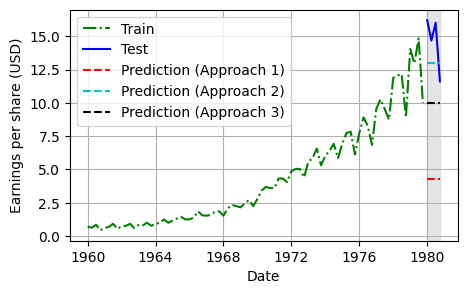

In [10]:
plt.figure(figsize = (5, 3))
plt.plot(train.index, train['EPS'], 'g-.', label='Train')
plt.plot(test.index, test['EPS'], 'b-', label='Test')
plt.plot(test.index, test['pred_mean'], 'r--', label='Prediction (Approach 1)')
plt.plot(test.index, test['pred_last_yr_mean'], 'c--', label='Prediction (Approach 2)')
plt.plot(test.index, test['pred_last_last_known_val'], 'k--', label='Prediction (Approach 3)')
plt.axvspan('1980-01-01', '1980-10-01', color='#808080', alpha=0.2)
plt.ylabel('Earnings per share (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

### Approach 4. Predicting using Seasonal Naive

In [11]:
seasonal_naive = train['EPS'].values[-4:]
print("Seasonal Naive: ", seasonal_naive)

test['seasonal_naive'] = seasonal_naive
print("MAPE: ", mean_absolute_percentage_error(test['EPS'], test['seasonal_naive']))

Seasonal Naive:  [14.04 12.96 14.85  9.99]
MAPE:  0.11561658552433654


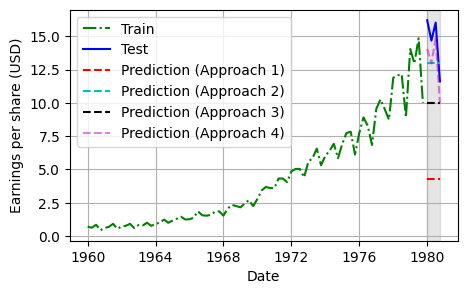

In [12]:
plt.figure(figsize = (5, 3))
plt.plot(train.index, train['EPS'], 'g-.', label='Train')
plt.plot(test.index, test['EPS'], 'b-', label='Test')
plt.plot(test.index, test['pred_mean'], 'r--', label='Prediction (Approach 1)')
plt.plot(test.index, test['pred_last_yr_mean'], 'c--', label='Prediction (Approach 2)')
plt.plot(test.index, test['pred_last_last_known_val'], 'k--', label='Prediction (Approach 3)')
plt.plot(test.index, test['seasonal_naive'], 'm--', alpha = 0.5, label='Prediction (Approach 4)')
plt.axvspan('1980-01-01', '1980-10-01', color='#808080', alpha=0.2)
plt.ylabel('Earnings per share (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.legend()
plt.show()

In [13]:
jj_eps['quarter'] = jj_eps.index.quarter
seaonal_avg_naive = jj_eps.groupby('quarter')['EPS'].mean().values

test['seasonal_avg_naive'] = seaonal_avg_naive
print("MAPE: ", mean_absolute_percentage_error(test['EPS'], test['seasonal_avg_naive']))

MAPE:  0.6692633587780972


### Approach: Average Seasonal Naive

In [14]:
# plt.figure(figsize = (5, 3))
# plt.plot(train.index, train['EPS'], 'g-.', label='Train')
# plt.plot(test.index, test['EPS'], 'b-', label='Test')
# plt.plot(test.index, test['pred_mean'], 'r--', label='Prediction (Approach 1)')
# plt.plot(test.index, test['pred_last_yr_mean'], 'c--', label='Prediction (Approach 2)')
# plt.plot(test.index, test['pred_last_last_known_val'], 'k--', label='Prediction (Approach 3)')
# plt.plot(test.index, test['seasonal_naive'], 'm--', alpha = 0.5, label='Prediction (Approach 4)')
# plt.plot(test.index, test['seasonal_avg_naive'], 'y--', alpha = 0.5, label='Prediction (Approach 5)')
# plt.axvspan('1980-01-01', '1980-10-01', color='#808080', alpha=0.2)
# plt.ylabel('Earnings per share (USD)')
# plt.xlabel('Date')
# plt.grid(True)
# plt.legend()
# plt.show()

# **Simulating Random Walk**

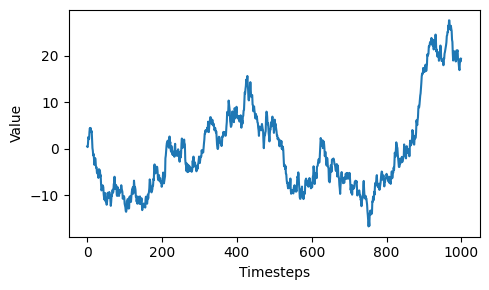

In [15]:
np.random.seed(42)
steps = np.random.standard_normal(1000)
random_walk = np.cumsum(steps)

fig, ax = plt.subplots(figsize = (5, 3))
ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
plt.tight_layout()

# **Simulating Stationary Time Series**

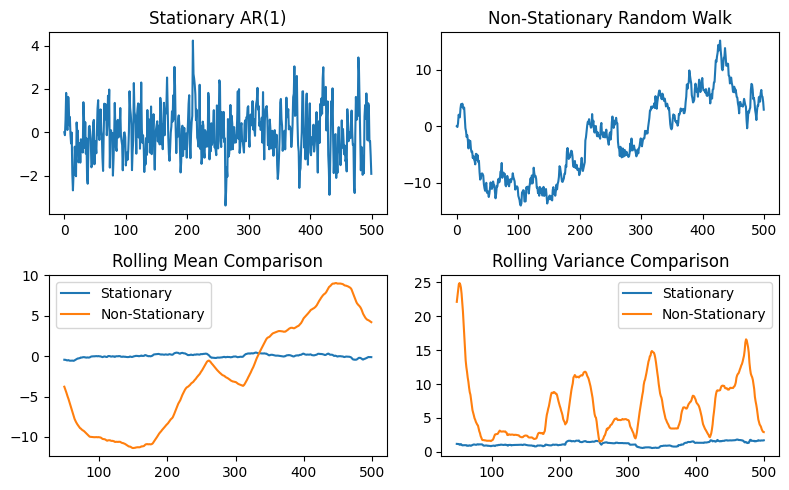

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

T = 500
epsilon = np.random.normal(0, 1, T)

# ---- Stationary AR(1) ----
y_stationary = np.zeros(T)
for t in range(1, T):
    y_stationary[t] = 0.5 * y_stationary[t-1] + epsilon[t]

# ---- Non-Stationary Random Walk ----
y_nonstationary = np.zeros(T)
for t in range(1, T):
    y_nonstationary[t] = y_nonstationary[t-1] + epsilon[t]

# Convert to pandas Series
y_stat = pd.Series(y_stationary)
y_nonstat = pd.Series(y_nonstationary)

window = 50

# Rolling statistics
roll_mean_stat = y_stat.rolling(window).mean()
roll_mean_nonstat = y_nonstat.rolling(window).mean()

roll_var_stat = y_stat.rolling(window).var()
roll_var_nonstat = y_nonstat.rolling(window).var()

# ---- Plotting 2x2 layout ----
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

# 1. Stationary Time Series
axes[0, 0].plot(y_stat)
axes[0, 0].set_title("Stationary AR(1)")

# 2. Non-Stationary Time Series
axes[0, 1].plot(y_nonstat)
axes[0, 1].set_title("Non-Stationary Random Walk")

# 3. Rolling Mean (Both in Same Graph)
axes[1, 0].plot(roll_mean_stat, label="Stationary")
axes[1, 0].plot(roll_mean_nonstat, label="Non-Stationary")
axes[1, 0].set_title("Rolling Mean Comparison")
axes[1, 0].legend()

# 4. Rolling Variance (Both in Same Graph)
axes[1, 1].plot(roll_var_stat, label="Stationary")
axes[1, 1].plot(roll_var_nonstat, label="Non-Stationary")
axes[1, 1].set_title("Rolling Variance Comparison")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [18]:
ADF_result = adfuller(random_walk)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.9659524876918764
p-value: 0.7654789696692577


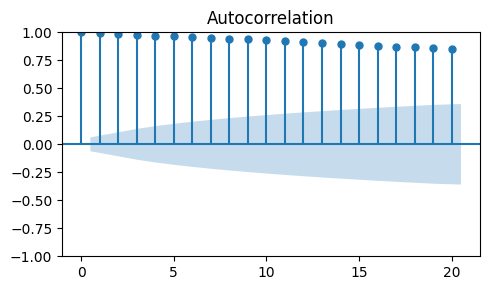

In [19]:
fig, ax = plt.subplots(figsize=(5, 3))   # control size here
plot_acf(random_walk, lags=20, ax=ax)

plt.tight_layout()
plt.show()

* Autocorrelation coefficients slowly decrease as the lag increases, which means our random walk is not a stationary process.
* Any point within the shaded region is not significant.

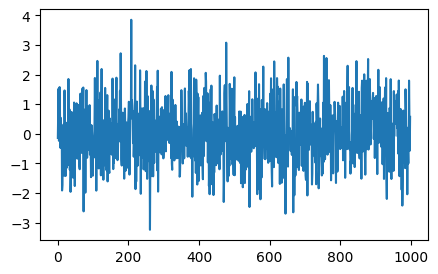

In [20]:
diff_random_walk = np.diff(random_walk, n=1)
plt.figure(figsize = (5, 3))
plt.plot(diff_random_walk)
plt.show()

In [21]:
# Here we pass in our differenced random walk.
ADF_result = adfuller(diff_random_walk)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -31.789310857560594
p-value: 0.0


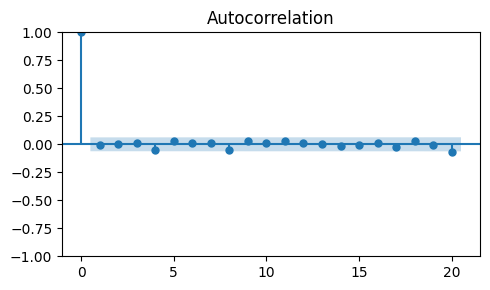

In [22]:
fig, ax = plt.subplots(figsize=(5, 3))   # control size here
plot_acf(diff_random_walk, lags=20, ax=ax)

plt.tight_layout()
plt.show()

* Series is uncorrelated.
* Since the first order differencing is stationary and uncorrelated, it is random walk

### Random Walk : Google Stock Price ?

In [23]:
import yfinance as yf
import pandas as pd

# Define the ticker symbol for Alphabet Inc. (Google)
ticker = "GOOGL"

# Fetch data for the last 5 years
google_stock = yf.Ticker(ticker).history(period="5y")

# Display the head and tail to confirm
google_stock.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-03-01 00:00:00-05:00,101.632092,103.033006,100.958183,102.706970,26060000,0.0,0.0
2021-03-02 00:00:00-05:00,102.467776,103.951567,102.062346,102.449913,25564000,0.0,0.0
2021-03-03 00:00:00-05:00,101.828114,103.021096,98.952336,99.816315,33892000,0.0,0.0
2021-03-04 00:00:00-05:00,99.988012,102.951620,99.519552,100.933868,49216000,0.0,0.0
2021-03-05 00:00:00-05:00,102.284663,104.520266,100.628672,104.067192,53100000,0.0,0.0


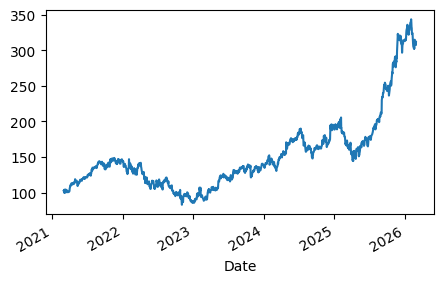

In [24]:
google_stock['Close'].plot(figsize = (5, 3))
plt.show()

In [25]:
GOOGL_ADF_result = adfuller(google_stock['Close'])
print(f'ADF Statistic: {GOOGL_ADF_result[0]}')
print(f'p-value: {GOOGL_ADF_result[1]}')

ADF Statistic: 1.0228087816771183
p-value: 0.9945008720392393


In [26]:
diff_close = np.diff(google_stock['Close'], n=1)
GOOGL_diff_ADF_result = adfuller(diff_close)
print(f'ADF Statistic: {GOOGL_diff_ADF_result[0]}')
print(f'p-value: {GOOGL_diff_ADF_result[1]}')

ADF Statistic: -35.307272362261024
p-value: 0.0


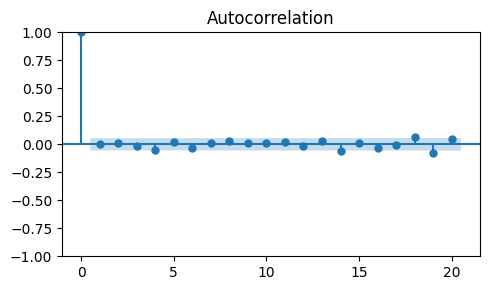

In [27]:
fig, ax = plt.subplots(figsize=(5, 3))   # control size here
plot_acf(diff_close, lags=20, ax=ax)

plt.tight_layout()
plt.show()

# **Forecasting Random Walk**

In [42]:
# Average, Last value baseline
# Drift Technique
train = random_walk[:800]
test = random_walk[800:]

deltaY = train[-1] - train[0]
deltaX = len(train)
drift = deltaY / deltaX

x_vals = np.arange(800, 1001, 1)

forecast = drift*x_vals
print(forecast[:5])

[-6.8149475  -6.82346618 -6.83198487 -6.84050355 -6.84902224]
